# Scaling study

In [9]:
import sys; sys.path.insert(0, "../../..")
%load_ext autoreload
%autoreload 2

from functools import partial

from algorithms.CMIICAdapter import CMIICAdapter
from algorithms.CPCAdapter import CPCAdapter

from data.generators import generate_from_sem, generate_from_cbn_dag
from experiments.scaling.runner import ScalingRunner
from experiments.scaling.plot import plot_facet, METRIC_NAMES
from experiments.scaling.io import load_results

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys, pyagrum, otagrum
print(sys.executable)          # doit contenir envs/cbnsl
print(pyagrum.__version__, otagrum.__version__)   # attendu : 3.0.0  0.15

/home/mathis/miniforge3/envs/cbnsl/bin/python
3.0.0 0.15


## Configuration

In [11]:
algo_configs = [
    ("CPC",   CPCAdapter,   {"alpha": 0.05, "max_conditioning_set_size": 3}),
    ("CMIIC", CMIICAdapter, {"alpha": 0.05}),
]

generator = partial(generate_from_cbn_dag, marginal_type="Uniform", lcc_types="NormalCopula")


runner = ScalingRunner(
    algo_configs=algo_configs,
    generator=generator,
    generator_name="cbn_unif_gauss",
    n_vars_list=[10],#, 20],
    n_samples_list=[200, 500, 1000, 3000, 5000],
    density=1.5,
    n_graphs=30,
    seed=42,
)


"""
#quick test
runner = ScalingRunner(
    algo_configs=algo_configs,
    generator=generator,
    generator_name="cbn_unif_gauss",
    n_vars_list=[10],
    n_samples_list=[200, 500],
    density=1.5,
    n_graphs=30,
    seed=42,
)
"""

'\n#quick test\nrunner = ScalingRunner(\n    algo_configs=algo_configs,\n    generator=generator,\n    generator_name="cbn_unif_gauss",\n    n_vars_list=[10],\n    n_samples_list=[200, 500],\n    density=1.5,\n    n_graphs=30,\n    seed=42,\n)\n'

## Run

In [ ]:
df = runner.run()

## (ou charger des résultats existants)

In [ ]:
#df = load_results("results/2026-03-27_13h11_cbn_unif_mixture/results.csv")

## Visualisation

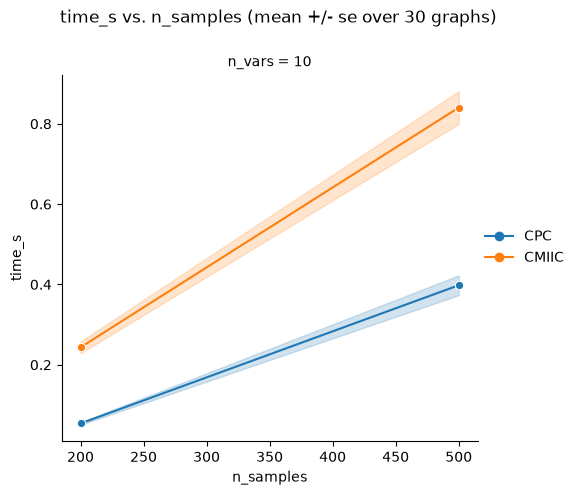

In [ ]:
plot_facet(df, y="time_s", col="n_vars"); # Temps de calcul

## Métriques

### Sur les CPDAG

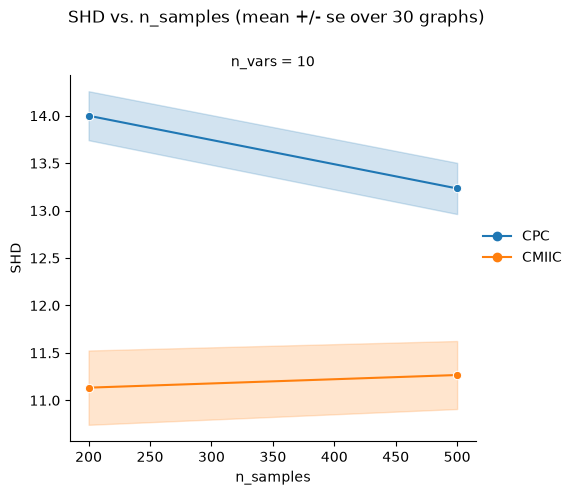

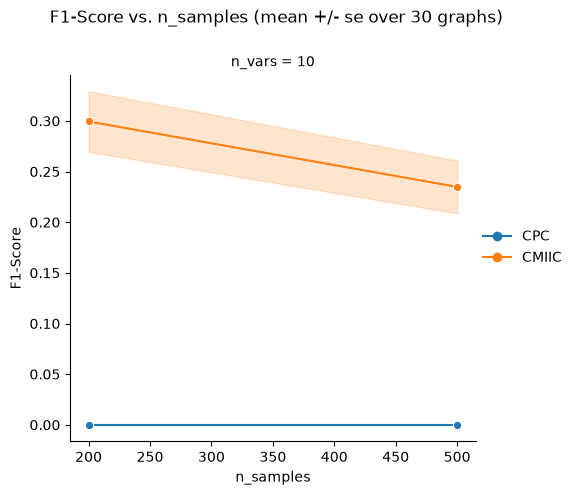

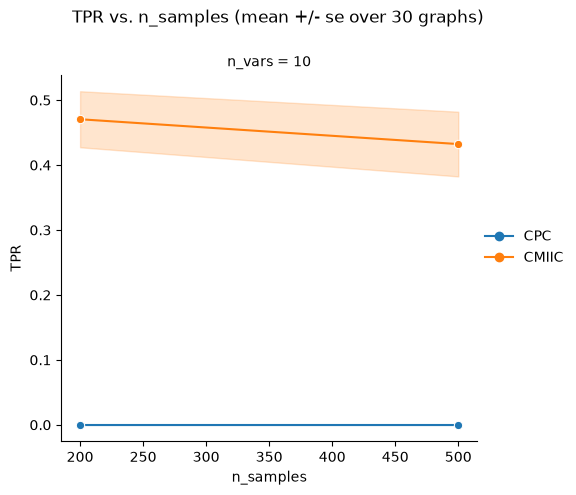

In [ ]:
for metric in METRIC_NAMES:
    plot_facet(df, y=metric, col="n_vars");

### Sur les squelettes

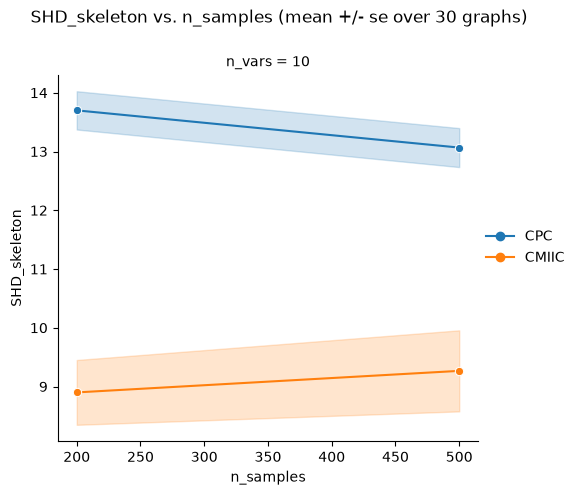

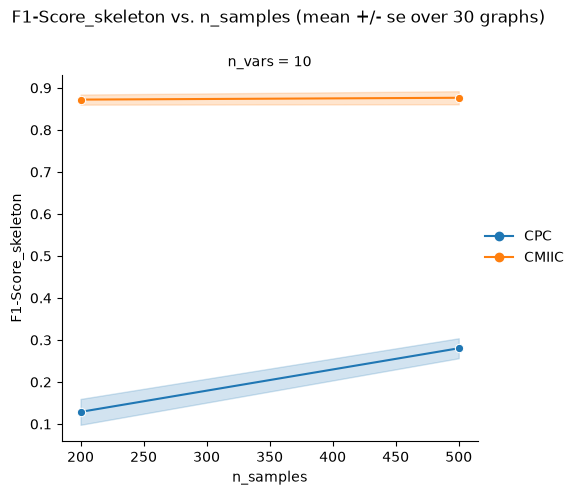

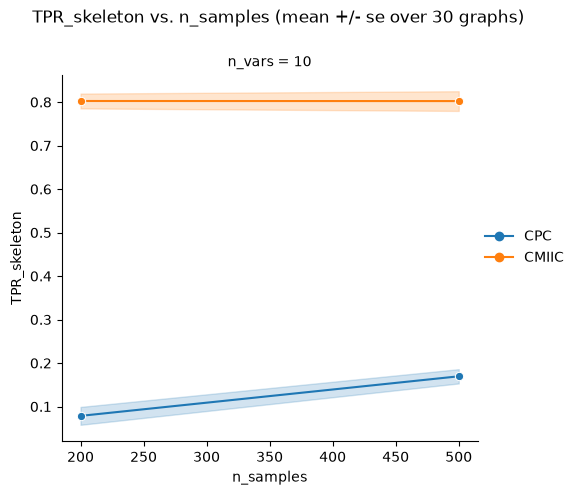

In [ ]:
for metric in METRIC_NAMES:
    plot_facet(df, y=f"{metric}_skeleton", col="n_vars");